# Programa Ejemplo para Realizar Aprendizaje Supervisado utilizando aprendizaje profundo

## Etapa 1: Carga de los datos.

Antes de comenzar a definir la red neuronal, cargamos la base de datos de interés. Para este ejemplo, usaremos la base de datos MNIST, la cual consiste en identificar dígitos escritos a mano alzada https://keras.io/api/datasets/mnist/. Esta base de datos configura un problema de 10 clases, una clase por cada dígito numérico (0-9).

Se cargan las librerías necesarias

In [2]:
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from keras.utils import plot_model
from tensorflow.keras.layers import Dense, Dropout

Se carga la base de datos y se divide en los conjuntos de entrenamiento y prueba. Hay 60000 imágenes para el entrenamiento y 10000 en el conjunto de prueba.

In [3]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

In [4]:
print(x_train.shape)

(60000, 28, 28)


Las imágenes tienen tamaño de 28x28. A continuación, se muestran algunos ejemplos.


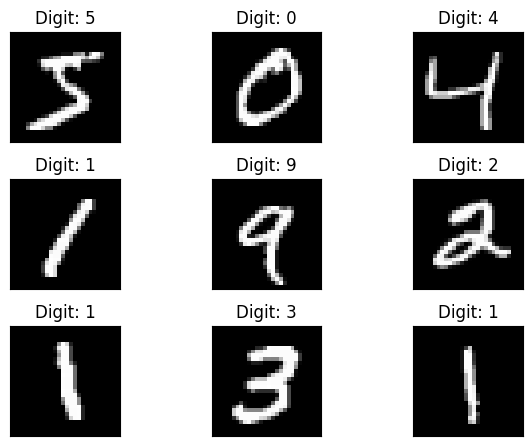

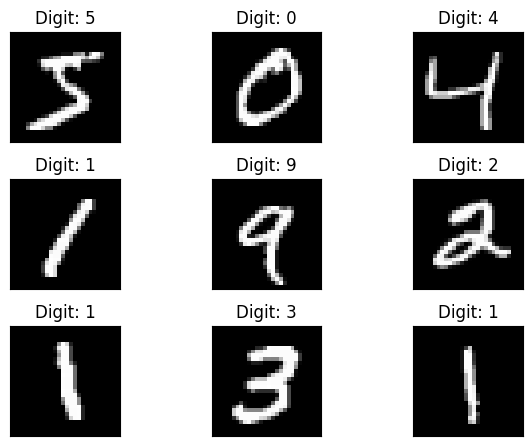

In [5]:
fig = plt.figure()
for i in range(9):
  plt.subplot(3,3,i+1)
  plt.tight_layout()
  plt.imshow(x_train[i], cmap='gray', interpolation='none')
  plt.title("Digit: {}".format(y_train[i]))
  plt.xticks([])
  plt.yticks([])
fig

Dado que este ejercicio es introductorio solo usaremos la forma más básica de una red neuronal, denominada densa. Esta versión no tiene la capacidad de manipular imágenes en su forma original. Así, aplicaremos una etapa de preprocesamiento a cada imagen con el fin de que las imágenes sean compatibles con las entradas de la red.

In [6]:
d1, d2, d3 = x_train.shape
x_train_flat = x_train.reshape((d1, d2*d3))/255
d1, d2, d3 = x_test.shape
x_test_flat = x_test.reshape((d1, d2*d3))/255

La operación llevada a cabo se denomina "aplastamiento" y consiste en convertir un arreglo de dos o más dimensiones en uno de una dimensión. El aplastamiento o flatten consiste en unir las columnas del arreglo (ver https://www.google.com/url?sa=i&url=https%3A%2F%2Fwww.w3resource.com%2Fnumpy%2Fmanipulation%2Fndarray-flatten.php&psig=AOvVaw2gj8sBNDTeO-t_T_R15TWv&ust=1675298541750000&source=images&cd=vfe&ved=0CBAQjRxqFwoTCPi0xsWL8_wCFQAAAAAdAAAAABAE)

In [7]:
print(x_train_flat.shape)

(60000, 784)


Se mantienen las mismas 60000 imágenes del entrenaminento y se obtienen 784 atributos luego del proceso de aplastamiento. 28*28=784.

## Etapa 2: Definición de la red.

Ahora podemos empezar a construir la red neuronal para resolver el problema de clasificación planteado. Keras tienen dos formas para definir una red neuronal. La API secuencial (https://keras.io/guides/sequential_model/) y la API funcional (https://keras.io/guides/functional_api/). En este ejemplo usaremos las API secuencial.

### 2.1 Definición de la red usando la API secuencial.

Se define una red con tres capas: dos ocultas y una de salida. Para este ejemplo el tipo de capas usada es la "Dense", en unidades posteriores usaremos otro tipo de capas como las convolucionales y las recurrentes.

In [8]:
model = Sequential()

from tensorflow.keras.layers import Dense, Dropout

model = Sequential()

model.add(Dense(512, activation='relu', input_shape=(784,)))
model.add(Dropout(0.2))

model.add(Dense(256, activation='relu'))
model.add(Dropout(0.2))

model.add(Dense(128, activation='relu'))

model.add(Dense(10, activation='softmax'))

d:\OneDrive - Grupo EPM\8. UNIVERSIDAD JAVERIANA\Deep Learning\Cap 1\Actividad 1\.venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [9]:
# Con model.summary() podemos verificar las capas que definimos y la cantidad de
# parámetros en cada capa.
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 567,434 (2.16 MB)

 Trainable params: 567,434 (2.16 MB)

 Non-trainable params: 0 (0.00 B)

In [10]:
plot_model(model)

You must install pydot (`pip install pydot`) for `plot_model` to work.


In [11]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [12]:
# Ahora, es momento de entrenar la red neuronal, lo cual corresponde a calcular
# parámetros de la red.
# 1. Se pasan los datos de entrenamiento x_train y y_train.
# 2. El número de épocas, en este caso, obedece a la cantidad de repeticiones
#    del entrenamiento.
# 3. El batch_size, será un parámetro que discutiremos en la siguiente unidad,
#    por ahora lo fijamos para que sea igual a la cantidad de muestras en el
#.   conjunto de entrenamiento.
history = model.fit(

    x_train_flat, y_train,

    epochs=20,

    batch_size=128,

    validation_data=(x_test_flat, y_test)

)

Epoch 1/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9175 - loss: 0.2730 - val_accuracy: 0.9633 - val_loss: 0.1193
Epoch 2/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9667 - loss: 0.1101 - val_accuracy: 0.9759 - val_loss: 0.0768
Epoch 3/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9748 - loss: 0.0804 - val_accuracy: 0.9765 - val_loss: 0.0737
Epoch 4/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9805 - loss: 0.0631 - val_accuracy: 0.9766 - val_loss: 0.0725
Epoch 5/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9833 - loss: 0.0509 - val_accuracy: 0.9779 - val_loss: 0.0755
Epoch 6/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9852 - loss: 0.0450 - val_accuracy: 0.9786 - val_loss: 0.0680
Epoch 7/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9867 - loss: 0.0409 - val_accuracy: 0.9803 - val_loss: 0.0683
Epoch 8/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9887 - loss: 0.0364 - val_accuracy: 0.

In [13]:
test_loss, test_acc = model.evaluate(x_test_flat, y_test)
print('test_acc:', test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9842 - loss: 0.0691
test_acc: 0.9842000007629395


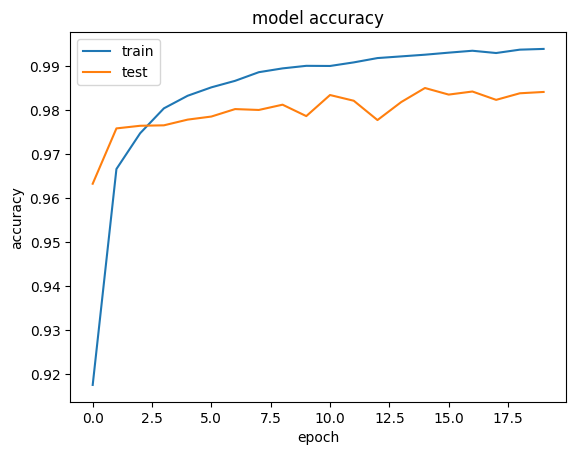

In [14]:
# Graficar los resultados
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()

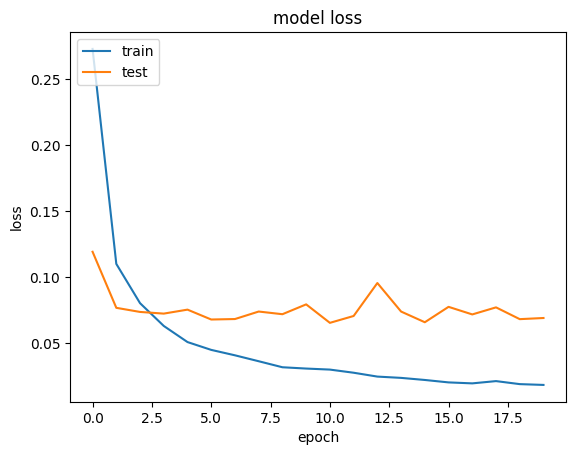

In [15]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()